In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))


from cxai import factory, inspector, constants, drsa
from cxai import utils as putils

from matplotlib import pyplot as plt

from tqdm import tqdm

import numpy as np
import pickle
import scipy.ndimage

from utils import utils_edited as utils
import wfdb
import pandas as pd
import ast
import torch

import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

# Introduction


In `./disentangled-explanations.ipynb`, we use these two sets of vectors (`arr_act` and `arr_ctx`) to learn the PRCA basis. These vectors are pre-extracted from a large set of training images from Class Basketball.


This notebook demonstrates how to extract such vectors from a set of images; for the sake of demonstration, we use only four images.

## Preparing Model and Explainer

In [16]:
# Pfad zum Datenverzeichnis, enthält Trainingsbilder und andere Datensätze
DATA_DIR = "C:/Users/AliceKitchkin/Repos/ecg_classification/data/ptbxl/"

# Definiert die Modellarchitektur
ARCH = "xresnet1d101-ecg" #torchvision-vgg16-imagenet"

# Konvertiert die NSID in einen numerischen Index, dieser numerische Wert wird vom Modell für Klassifikation verwendet
# Für EKG: Direkt den numerischen Label für EKG-Klasse verwenden
# 0 = MI, 1 = OTHER, 2 = NORM
LABEL = 2 # putils.imagenet.get_index_from_imagenet_id(NSID)
CLASS_NAMES = ['CD', 'HYP', 'MI', 'NORM', 'STTC'] #["MI", "OTHER", "NORM"]

EXPERIMENT = "exp1.1"
TASK = "superdiagnostic"
SAMPLING_FREQUENCY = 100

standard_scaler = pickle.load(open(f'../../output/{EXPERIMENT}/data/standard_scaler.pkl', "rb"))

In [3]:
model, (rc_transform, input_transform) = factory.make_model(ARCH, CLASS_NAMES, standard_scaler)

In [4]:
explainer = factory.make_explainer("gradcam", model)
print(f"Created explainer: {type(explainer)}")

# explainer.target_layer = "7.2"  # oder "7.2.act" für die ReLU
# logits, heatmap = explainer.explain(x)

Created explainer: <class 'cxai.explainers.gradcam.GradCAMExplainer'>


## Load Data

In [5]:
outputfolder_for_mlb = f'../../output/{EXPERIMENT}/'

# Load PTB-XL data
df, raw_labels = utils.load_dataset(DATA_DIR, SAMPLING_FREQUENCY)

# Preprocess label data
labels =  utils.compute_label_aggregations(raw_labels, DATA_DIR, TASK)

# Select relevant data and convert to one-hot
X, Y, y, mlb =  utils.select_data(df, labels, TASK, min_samples=0, output_folder=outputfolder_for_mlb)

Y

Loading PTB-XL data from: C:/Users/AliceKitchkin/Repos/ecg_classification/data/ptbxl/ ptbxl_database.csv


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_codes_len,superdiagnostic,superdiagnostic_len
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,3,[NORM],1
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,2,[NORM],1
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,2,[NORM],1
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,2,[NORM],1
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,2,[NORM],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,...,NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,4,[STTC],1
21834,20703.0,300.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,3,[NORM],1
21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,...,NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,2,[STTC],1


## Split Data

In [6]:
# 1-8 for training 
X_train = X[Y.strat_fold < 9]
y_train = y[Y.strat_fold < 9]

# 9 for validation
X_val = X[Y.strat_fold == 9]
y_val = y[Y.strat_fold == 9]

# 10 for testing
X_test = X[Y.strat_fold == 10]
y_test = y[Y.strat_fold == 10]

## Plot

In [7]:
training_ecgs = X_train[:3]
print(f"Training ECG shapes: {[ecg.shape for ecg in training_ecgs]}")
print(f"Expected shape: (1000, 12) für 10s ECG mit 12 Leads")

Training ECG shapes: [(1000, 12), (1000, 12), (1000, 12)]
Expected shape: (1000, 12) für 10s ECG mit 12 Leads


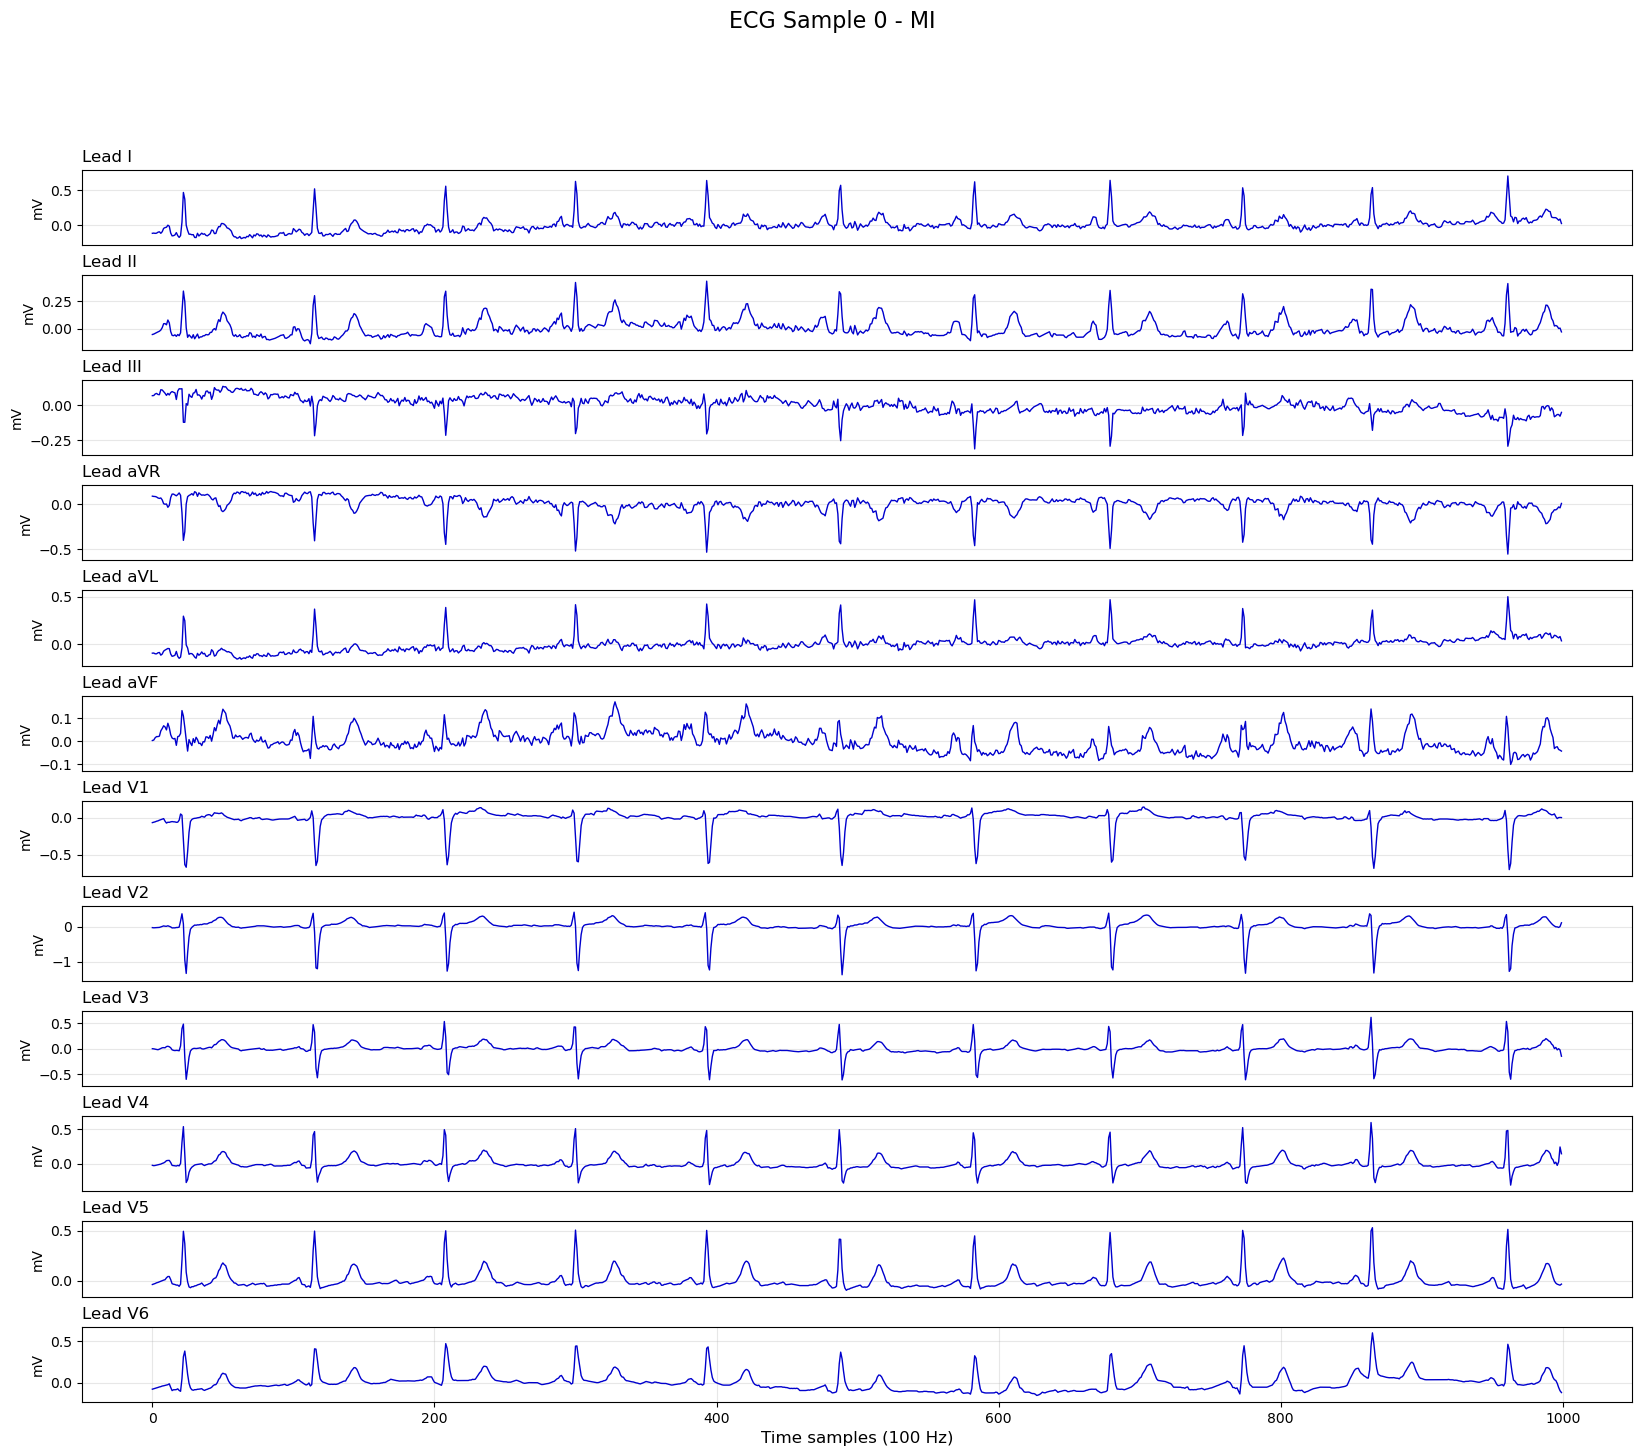

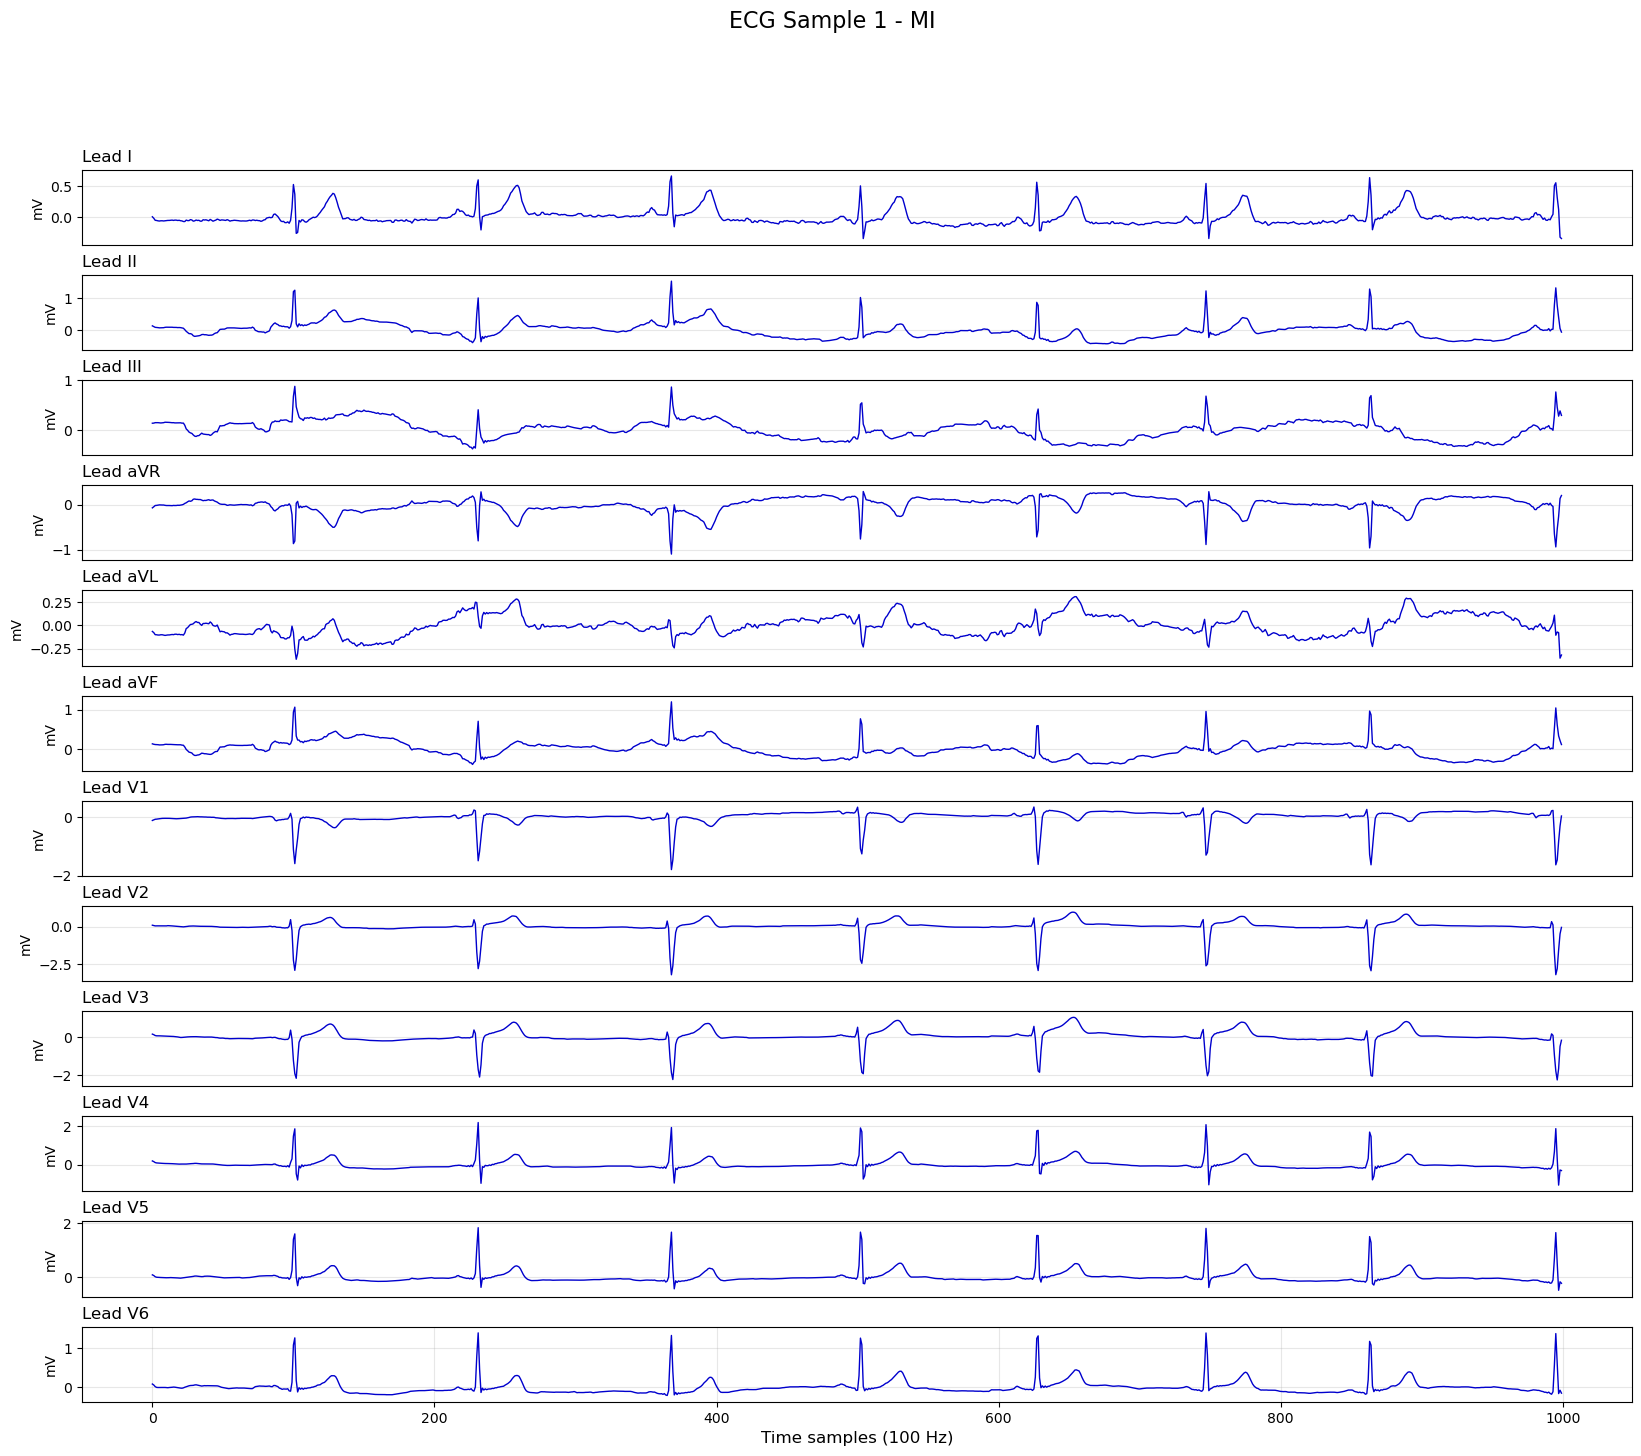

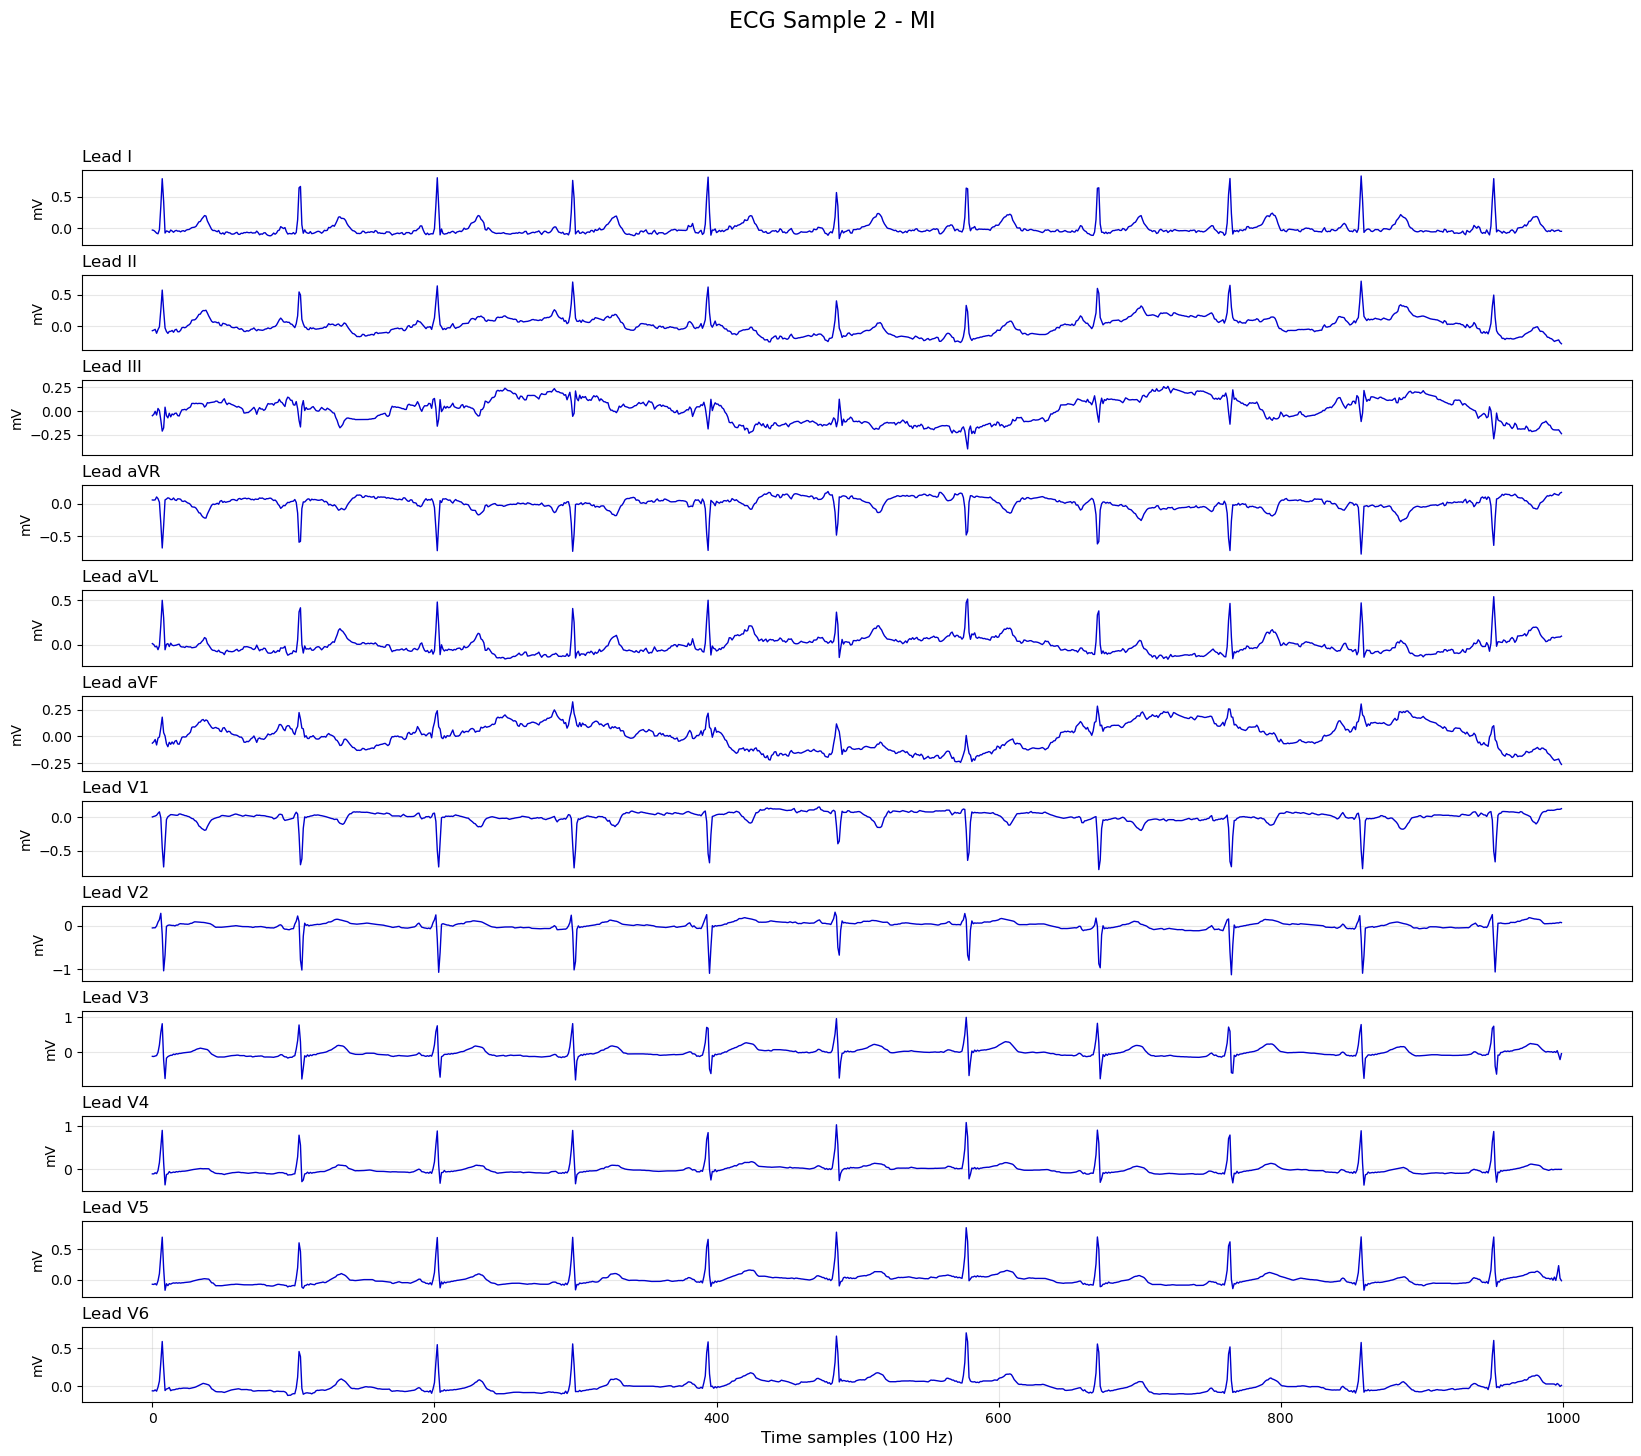

In [8]:
def visualize_ecgs():
    # Lead-Namen für bessere Beschriftung
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    
    for ecg_idx, ecg_sample in enumerate(training_ecgs):
        plt.figure(figsize=(20, 16))  # Höher für mehr Platz
        plt.suptitle(f'ECG Sample {ecg_idx} - {CLASS_NAMES[LABEL]}', fontsize=16, y=0.98)
        
        # 12x1 Layout - alle Leads untereinander
        for lead_idx in range(12):
            plt.subplot(12, 1, lead_idx + 1)  # Korrigiert: 12, nicht 14
            plt.plot(ecg_sample[:, lead_idx], linewidth=1, color='mediumblue')
            plt.title(f'Lead {lead_names[lead_idx]}', fontsize=12, loc='left')
            plt.ylabel('mV', fontsize=10)
            plt.grid(True, alpha=0.3)
            
            # Y-Achse für bessere Lesbarkeit anpassen
            y_margin = (ecg_sample[:, lead_idx].max() - ecg_sample[:, lead_idx].min()) * 0.1
            plt.ylim(ecg_sample[:, lead_idx].min() - y_margin, 
                    ecg_sample[:, lead_idx].max() + y_margin)
            
            # Nur beim letzten Plot X-Label setzen
            if lead_idx == 11:
                plt.xlabel('Time samples (100 Hz)', fontsize=12)
            else:
                plt.xticks([])  # X-Achsen-Labels ausblenden für bessere Übersicht
        
        # Wichtig: Mehr Abstand zwischen Subplots
        #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.subplots_adjust(hspace=0.4)  # Erhöht den vertikalen Abstand zwischen Plots
        plt.show()

visualize_ecgs()

## Grad-CAM

In [9]:
print(f"Zeige Grad-CAM für Label: {CLASS_NAMES[LABEL]} (Index {LABEL})")

Zeige Grad-CAM für Label: MI (Index 2)


In [10]:
# Erzeuge die Heatmap für das erste Trainings-EKG
ecg = training_ecgs[0]
x = input_transform(ecg)
if not isinstance(x, torch.Tensor):
    x = torch.FloatTensor(x)
if x.dim() == 2:
    x = x.unsqueeze(0)
    x = x.transpose(1, 2)
elif x.dim() == 3 and x.shape == (1, 1000, 12):
    x = x.transpose(1, 2)

# Grad-CAM anwenden
logits, heatmap = explainer.explain(x, label=LABEL)

print("Logits:", logits)
print("Heatmap shape:", heatmap.shape)

Activations min/max/mean: tensor(0.) tensor(2.7804) tensor(0.2430)
Gradients min/max/mean: tensor(-0.1791) tensor(0.1580) tensor(-5.6609e-05)
Logits: [[-0.435661 -0.866587 -0.692772 -1.710036  0.634556]]
Heatmap shape: (32,)


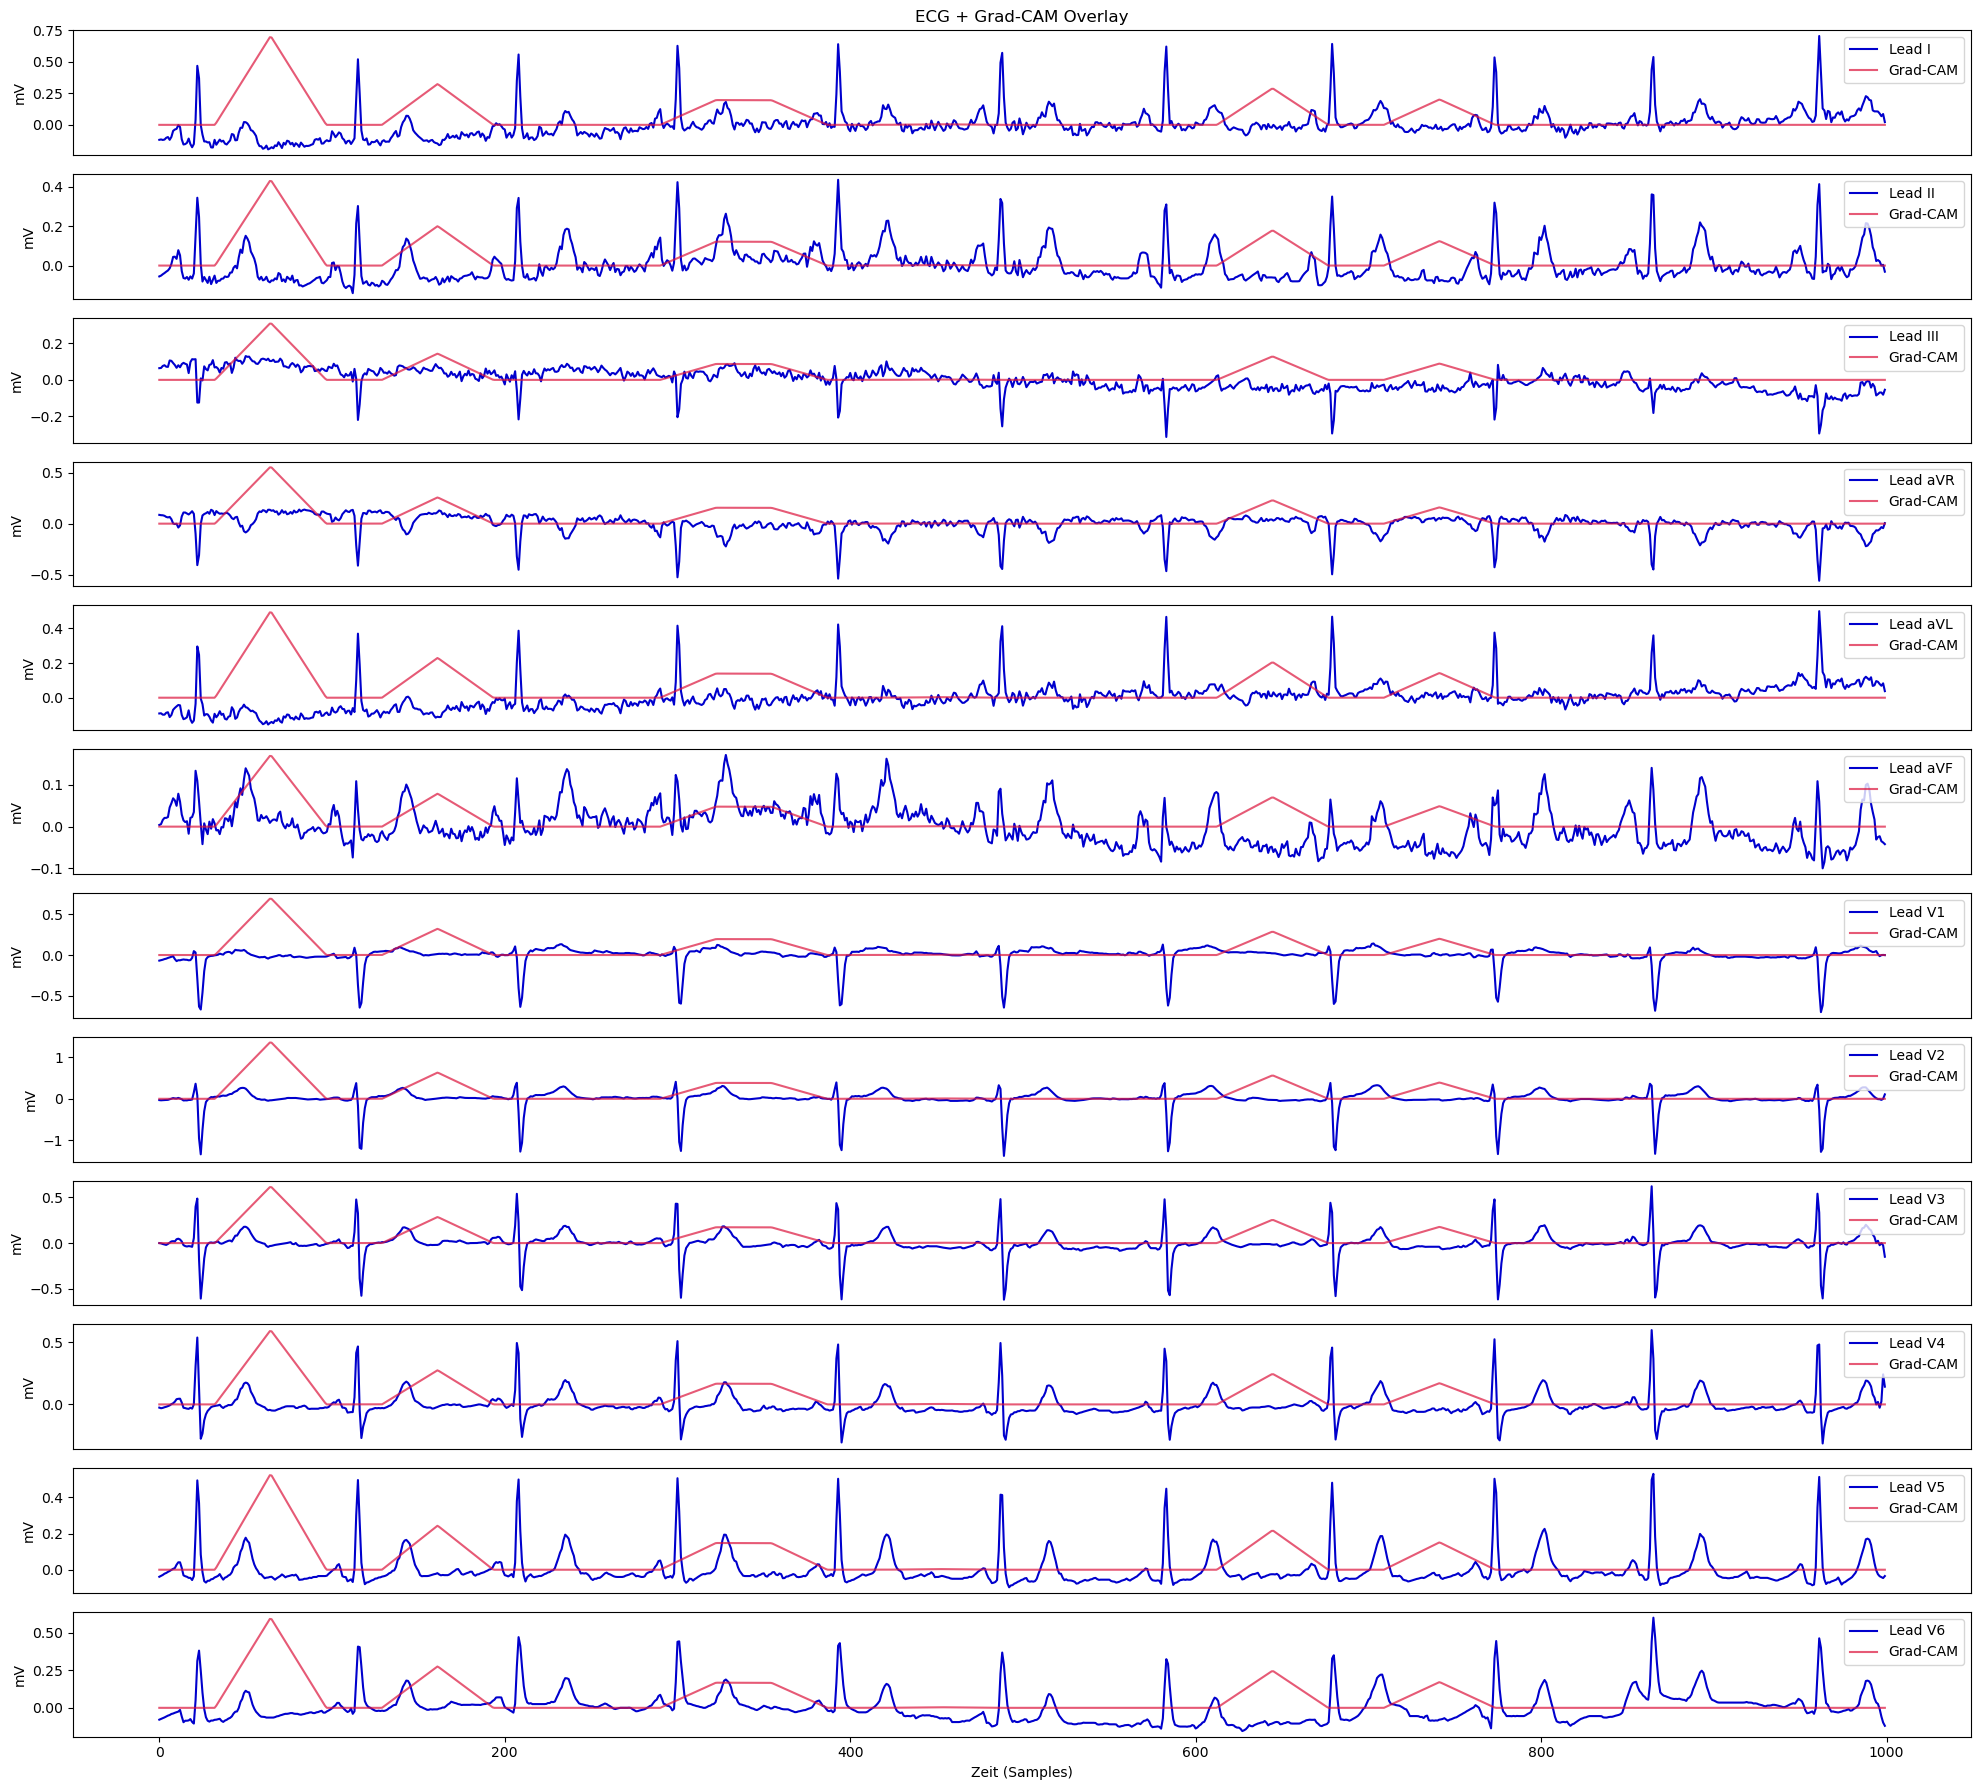

In [11]:
def plot_ecg_with_gradcam_overlay(ecg, heatmap, lead_names=None, title="ECG + Grad-CAM Overlay", smooth=False):
    """
    Plottet alle 12 Ableitungen eines EKGs mit Grad-CAM-Heatmap (ohne Glättung).
    
    Args:
        ecg: np.ndarray, shape (samples, 12)
        heatmap: np.ndarray, shape (n,) (z.B. 32), wird auf Länge des EKGs interpoliert
        lead_names: list of str, optional
        title: str
    """
    if lead_names is None:
        lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    # Interpolieren auf die Länge des Eingangssignals
    heatmap_interp = np.interp(
        np.linspace(0, len(heatmap)-1, ecg.shape[0]),
        np.arange(len(heatmap)),
        heatmap
    )

    if smooth==True:
        heatmap_interp = scipy.ndimage.gaussian_filter1d(heatmap_interp, sigma=10)


    plt.figure(figsize=(20, 18))
    for i in range(12):
        plt.subplot(12, 1, i+1)
        plt.plot(ecg[:, i], label=f"Lead {lead_names[i]}", color='mediumblue')
        plt.plot(heatmap_interp * np.max(np.abs(ecg[:, i])), label="Grad-CAM", color='crimson', alpha=0.7)
        plt.ylabel('mV')
        plt.legend(loc='upper right')
        if i == 0:
            plt.title(title)
        if i < 11:
            plt.xticks([])
    plt.xlabel('Zeit (Samples)')
    plt.tight_layout()
    plt.show()

plot_ecg_with_gradcam_overlay(training_ecgs[0], heatmap, smooth=False)

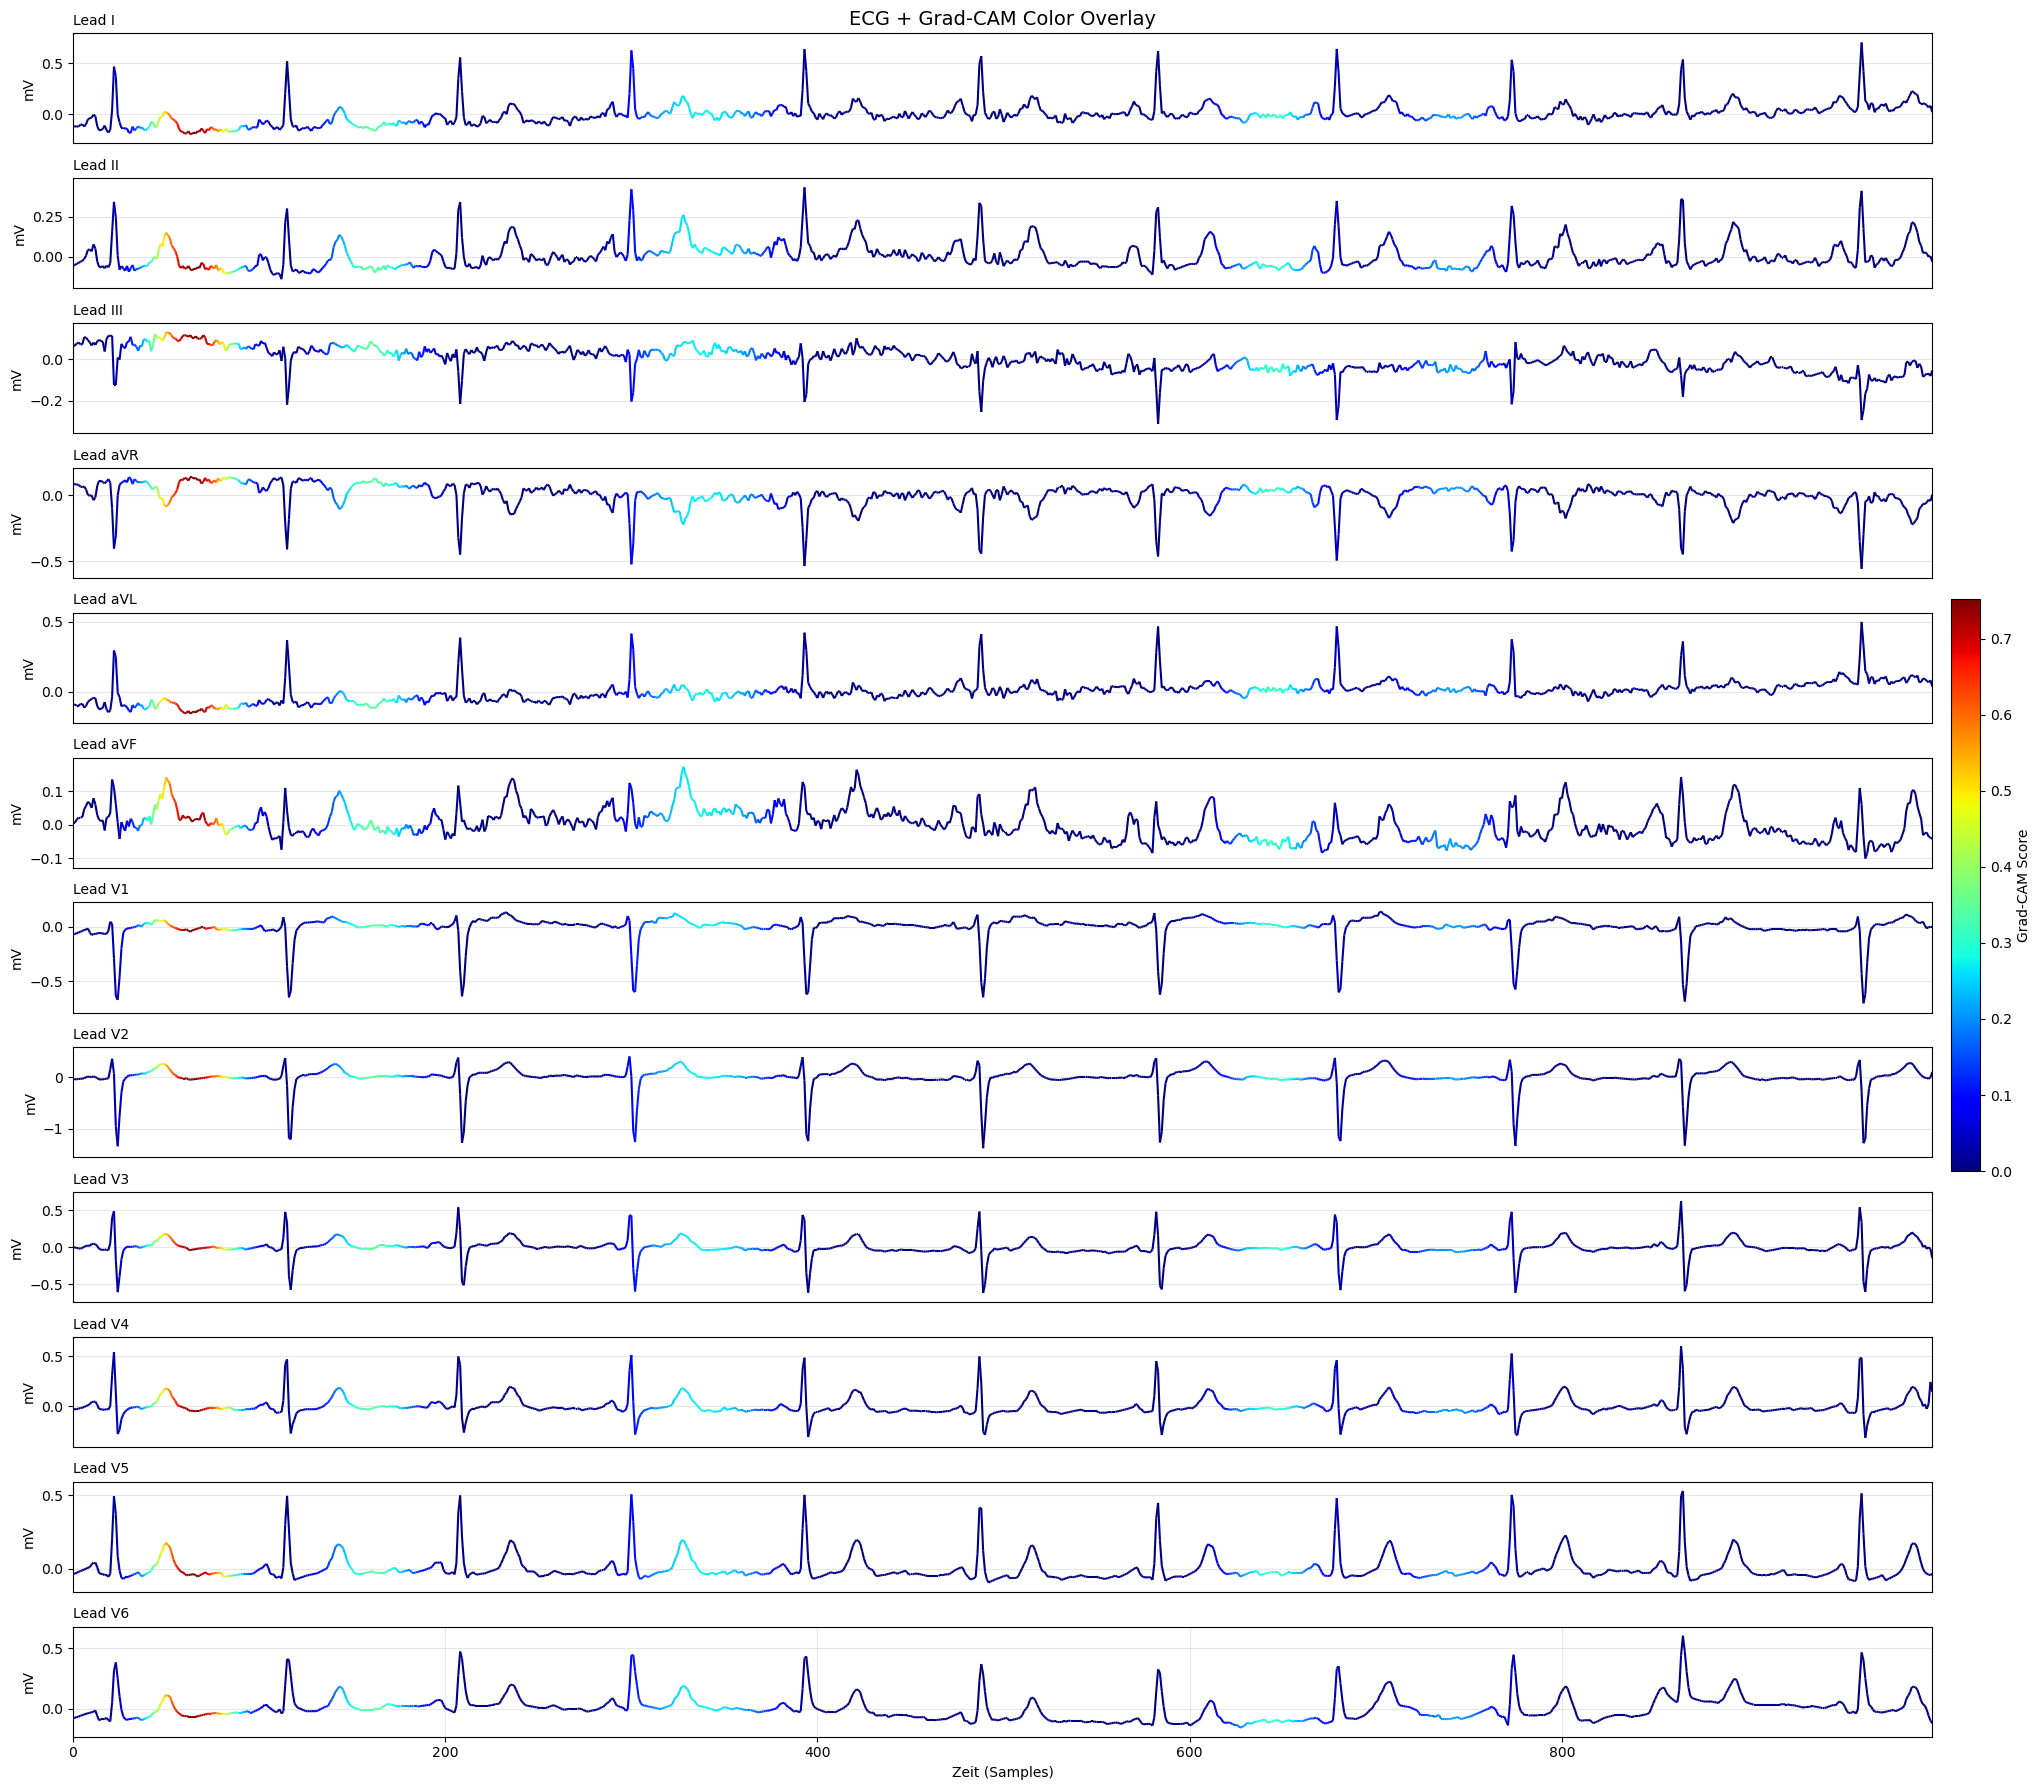

In [12]:
def plot_ecg_with_colored_gradcam(ecg, heatmap, lead_names=None, title="ECG + Grad-CAM Color Overlay", cmap="jet", smooth=False):
    """
    Plottet alle 12 Ableitungen eines EKGs, wobei die Linienfarbe je nach Grad-CAM-Score variiert.
    Args:
        ecg: np.ndarray, shape (samples, 12)
        heatmap: np.ndarray, shape (n,) (z.B. 32), wird auf Länge des EKGs interpoliert
        lead_names: list of str, optional
        title: str
        cmap: str, Colormap-Name
        smooth: bool, optional
    """
    if lead_names is None:
        lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    # Interpolieren auf die Länge des Eingangssignals
    heatmap_interp = np.interp(
        np.linspace(0, len(heatmap)-1, ecg.shape[0]),
        np.arange(len(heatmap)),
        heatmap
    )
    if smooth:
        heatmap_interp = scipy.ndimage.gaussian_filter1d(heatmap_interp, sigma=10)

    norm = mcolors.Normalize(vmin=np.min(heatmap_interp), vmax=np.max(heatmap_interp))
    cmap = plt.get_cmap(cmap)

    plt.figure(figsize=(20, 18))
    for i in range(12):
        plt.subplot(12, 1, i+1)
        x = np.arange(ecg.shape[0])
        y = ecg[:, i]
        # Für farbige Linien: Segmente erzeugen
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        # Die Farbe pro Segment ist der mittlere Heatmap-Wert des Segments
        values = (heatmap_interp[:-1] + heatmap_interp[1:]) / 2
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(values)
        lc.set_linewidth(1.5)
        plt.gca().add_collection(lc)
        plt.xlim(x[0], x[-1])
        plt.ylim(y.min() - 0.1*(y.max()-y.min()), y.max() + 0.1*(y.max()-y.min()))
        plt.ylabel('mV')
        plt.title(f"Lead {lead_names[i]}", loc='left', fontsize=10)
        if i == 0:
            plt.title(title, fontsize=14)
        if i < 11:
            plt.xticks([])
        plt.grid(True, alpha=0.3)
    plt.xlabel('Zeit (Samples)')
    plt.tight_layout()
    # Farbleiste nur einmal
    cbar = plt.colorbar(lc, ax=plt.gcf().axes, orientation='vertical', fraction=0.015, pad=0.01)
    cbar.set_label('Grad-CAM Score')
    plt.show()

# Beispielaufruf:
plot_ecg_with_colored_gradcam(training_ecgs[0], heatmap, smooth=True)

- Das EKG-Signal (blau) ist das Originalsignal der jeweiligen Ableitung
- Die Grad-CAM-Heatmap (rot) zeigt, an welchen Zeitpunkten das Modell besonders "aufmerksam" war, um seine Entscheidung zu treffen
- Hohe Werte der Heatmap bedeuten: Dieser Abschnitt war für die Klassifikation besonders wichtig
- Niedrige Werte: Wenig Einfluss auf die Entscheidung
- z.B. bei einem Infarkt die T-Welle oder der QRS-Komplex auffällig ist, sollte die Heatmap dort Peaks zeigen
- zeigt keine exakten medizinischen Marker, sondern die Modell-Aufmerksamkeit

# Extraction

In [13]:
%load_ext autoreload
%autoreload 2

In [14]:
def subsample_act_and_ctx(act, ctx, num_locations_selected=10):
    # Let
    # - `wh` be the number of spatial locations
    # - `n` be `num_locations_selected`
    # - `d` number of channels
    # The function selects the `d`-dimensional activation and context vectors of `n` random spatial locations from all `wh` locations.
    # Then, it returns each group of the vectors as a (n, d) matrix.

    assert len(act.shape) == 4 and act.shape == ctx.shape
    
    act = act.squeeze().detach().cpu().numpy()
    ctx = ctx.squeeze().detach().cpu().numpy()

    np.testing.assert_allclose(act.shape, ctx.shape)

    # FIX: Für 1D-CNNs haben wir nur 2D nach squeeze: (C, L)
    if len(act.shape) == 2:
        dim_c, dim_l = act.shape
        dim_h, dim_w = dim_l, 1  # Behandle Länge als Höhe, Breite = 1
    else:
        dim_c, dim_h, dim_w = act.shape

    total_spatial_locations = dim_h * dim_w

    # remarks:
    # - we assume the tensor in (c, h, w) where c is the dimension of channels;
    # - seed should be set outside.
    selected_locations = np.random.permutation(total_spatial_locations)[
        :num_locations_selected
    ]

    # Reshape für 2D Fall
    if len(act.shape) == 2:
        act_flatten = act.reshape((dim_c, total_spatial_locations))
        ctx_flatten = ctx.reshape((dim_c, total_spatial_locations))
    else:
        act_flatten = act.reshape((dim_c, total_spatial_locations))
        ctx_flatten = ctx.reshape((dim_c, total_spatial_locations))

    act_flatten_selected = act_flatten[:, selected_locations]
    ctx_flatten_selected = ctx_flatten[:, selected_locations]

    assert (
        act_flatten_selected.shape[1]
        == ctx_flatten_selected.shape[1]
        == num_locations_selected
    )

    return act_flatten_selected.T, ctx_flatten_selected.T, selected_locations

In [17]:
# num_locations_selected is a hyperparameter
def extract_activation_and_context(layer, num_locations_selected=20, seed=1):
    
    np.random.seed(1)
    
    arr_act, arr_ctx = [], []
    
    print(f"Extracting `activation` and `context` vectors from layer={layer} (subsampled to {num_locations_selected} locations)")

    for ix, ecg in enumerate(training_ecgs):
        print(f"------ [ECG {ix}] ------")

        x = input_transform(ecg)

        print(f"After input_transform: {x.shape}")
        print(f"Type: {type(x)}")

        # Konvertiere zu Tensor falls nötig
        if not isinstance(x, torch.Tensor):
            x = torch.FloatTensor(x)
        
        # Stelle sicher dass wir 3D haben: (batch, channels, time)
        if x.dim() == 2:  # (1000, 12) -> (1, 1000, 12) -> (1, 12, 1000)
            x = x.unsqueeze(0)  # Batch-Dimension hinzufügen: (1000, 12) -> (1, 1000, 12)
            x = x.transpose(1, 2)  # Dann transponieren: (1, 1000, 12) -> (1, 12, 1000)
        elif x.dim() == 3 and x.shape == (1, 1000, 12):  # Falls schon 3D aber falsche Reihenfolge
            x = x.transpose(1, 2)  # (1, 1000, 12) -> (1, 12, 1000)
        
        print(f"Final x shape: {x.shape}")
        
        layer_act, layer_ctx = explainer.get_intermediate_activation_and_context(
            layer=layer,
            x=x,
            label=LABEL
        )
        
        # shape of layer_act, layer_ctx: [1, d, h, w]
        assert layer_act.shape == layer_ctx.shape
        assert len(layer_act.shape) == 4
        
        print(f">            act.shape={tuple(layer_act.shape)}")
        
        layer_act_subsampled, layer_ctx_subsampled, _ = subsample_act_and_ctx(
            layer_act,
            layer_ctx,
            num_locations_selected=num_locations_selected
        )
        
        print(f"> act_subsampled.shape={layer_act_subsampled.shape}")

        arr_act.append(layer_act_subsampled)
        arr_ctx.append(layer_ctx_subsampled)
        
    
    arr_act = np.concatenate(arr_act)
    arr_ctx = np.concatenate(arr_ctx)
    
    assert arr_act.shape[0] == len(training_ecgs) * num_locations_selected
    
    return arr_act, arr_ctx

LAYER = '7.2'
arr_act, arr_ctx = extract_activation_and_context(LAYER)

Extracting `activation` and `context` vectors from layer=7.2 (subsampled to 20 locations)
------ [ECG 0] ------
After input_transform: (1000, 12)
Type: <class 'numpy.ndarray'>
Final x shape: torch.Size([1, 12, 1000])
>            act.shape=(1, 1, 256, 32)
> act_subsampled.shape=(20, 256)
------ [ECG 1] ------
After input_transform: (1000, 12)
Type: <class 'numpy.ndarray'>
Final x shape: torch.Size([1, 12, 1000])
>            act.shape=(1, 1, 256, 32)
> act_subsampled.shape=(20, 256)
------ [ECG 2] ------
After input_transform: (1000, 12)
Type: <class 'numpy.ndarray'>
Final x shape: torch.Size([1, 12, 1000])
>            act.shape=(1, 1, 256, 32)
> act_subsampled.shape=(20, 256)


In [18]:
# Erstelle Ordner im cxai-Verzeichnis
CXAI_DATA_DIR = "../cxai/data/ecg/"
ECG_SAVE_DIR = f"{CXAI_DATA_DIR}/{EXPERIMENT}/{TASK}/layer_{LAYER}"

os.makedirs(ECG_SAVE_DIR, exist_ok=True)

# Speichere die Arrays
np.save(f"{ECG_SAVE_DIR}/act.npy", arr_act)
np.save(f"{ECG_SAVE_DIR}/ctx.npy", arr_ctx)

print(f"Gespeichert in cxai/data/:")
print(f"  - arr_act: {ECG_SAVE_DIR}/act.npy")
print(f"  - arr_ctx: {ECG_SAVE_DIR}/ctx.npy")
print(f"  - Shapes: {arr_act.shape}, {arr_ctx.shape}") # shape: [total images x num_locations, d]

Gespeichert in cxai/data/:
  - arr_act: ../cxai/data/ecg//exp1.1/superdiagnostic/layer_7.2/act.npy
  - arr_ctx: ../cxai/data/ecg//exp1.1/superdiagnostic/layer_7.2/ctx.npy
  - Shapes: (60, 256), (60, 256)
